# Bayesian Inference III
# Bayesian Regression Extended

This article is part of a series:

- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Bayesian%20Inference%20I%20-%20Bayesian%20Inference.ipynb">Bayesian Inference I - Bayesian Inference</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Bayesian%20Inference%20II%20-%20Bayesian%20Linear%20Regression.ipynb">Bayesian Inference II - Bayesian Linear Regression</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Bayesian%20Inference%20III%20-%20Extending%20Bayesian%20Regression.ipynb">Bayesian Inference III - Extending Bayesian Regression</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Bayesian%20Inference%20IV%20-%20EBayesian%20Networks%20Discrete.ipynb">Bayesian Inference IV - Discrete Bayesian Networks</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Bayesian%20Inference%20V%20-%20EBayesian%20Networks%20Continuous%20and%20Hybrid.ipynb">Bayesian Inference V - Continuous and Hybrid Bayesian Networks</a>
- <a href="">Bayesian Inference VI - Generalized Bayesian Networks (under construction)</a>

## Outline

<ul>
    <li>The Generalized Model (GLM)</li>
    <li>Poisson Regression</li>
    <li>Zero-Inflated Poisson Regression</li>
    <li>Negative Binomial Regression</li>
    <li>Zero-Inflated Negative Binomial Regression</li>
    <li>Gamma Regression</li>
</ul

## The Generalized Linear Model

The GLM is a generalization of the linear model that allows us to use different distributions for the likelihood. It is defined as $Y \sim \phi(f(\mu), \theta)$, where $\phi$ is an arbitrary distribution, such as the Poisson, Negative Binomial, Gamma, or Student's t. $\theta$ represents the auxiliary parameters of the distribution, such as $\sigma$ for the Normal.

$f$ is called the inverse link function. When $\phi$ is Normal, $f$ is the identity function, whereas for distributions like the Gamma and Negative Binomial, $f$ is usually the exponential function. The output of the Normal linear model will generally fall on the real line, and $f$ facilitates any required transformations, such as to ensure the output is strictly positive, or integer-valued.

## Poisson Regression

As mentioned earlier, the Normal model outputs numbers on the real line, including negative numbers and non-integers. For modeling discrete counts of events that occur in a fixed interval of time or space, assuming a Poisson distribution may be more reasonable. It is also handy if the data is right-skewed. We write:

- $Y_i | \lambda_i \sim Pois(\lambda_i)$
- $E(Y_i | \lambda_i) = \lambda_i$

As in Normal regression, we assume that the average result is a linear combination of our predictors. It is common to use a log link function.

- $Y_i | \alpha, \beta_1, \ldots, \beta_p \sim Pois(\lambda_i)$
- $log(\lambda_i) = \alpha + \beta_1 X_1 + \ldots + \beta_p X_p$
- $\lambda_i = exp(\alpha + \beta_1 X_1 + \ldots + \beta_p X_p)$

The word poisson is french for fish, so how appropriate it is that there is a fishing-related dataset which provides a natural example for modeling low-valued count data. It tracks the number of fish caught by each group of visitors to a natural park which also hosts a campground. The features include:
- <code>livebait</code>: whether the visitor brought live bait
- <code>camper</code>: whether the visitor was a camper
- <code>persons</code>: number of visitors in the group
- <code>child</code>: number of children in the group
- <code>count</code>: number of fish caught (I'll rename it to <code>numfish</code>)

In [2]:
# !pip install bambi

In [3]:
import pandas as pd
import bambi as bmb
import numpy as np
import pymc as pm
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az

plt.style.use('seaborn-v0_8-darkgrid')

In [4]:
data = pd.read_csv("https://stats.idre.ucla.edu/stat/data/fish.csv")
cols = ["count", "livebait", "camper", "persons", "child"]
data = data[cols]
data = data.rename(columns={"count": "numfish"})

data["child"] = data["child"].astype(int)

In [5]:
data.describe()

,numfish,livebait,camper,persons,child
count,250.000000,250.000000,250.000000,250.00000,250.000000
mean,3.296000,0.864000,0.588000,2.52800,0.684000
std,11.635028,0.343476,0.493182,1.11273,0.850315
min,0.000000,0.000000,0.000000,1.00000,0.000000
25%,0.000000,1.000000,0.000000,2.00000,0.000000
50%,0.000000,1.000000,1.000000,2.00000,0.000000
75%,2.000000,1.000000,1.000000,4.00000,1.000000
max,149.000000,1.000000,1.000000,4.00000,3.000000


In [6]:
data["livebait"] = pd.Categorical(data["livebait"])
data["camper"] = pd.Categorical(data["camper"])

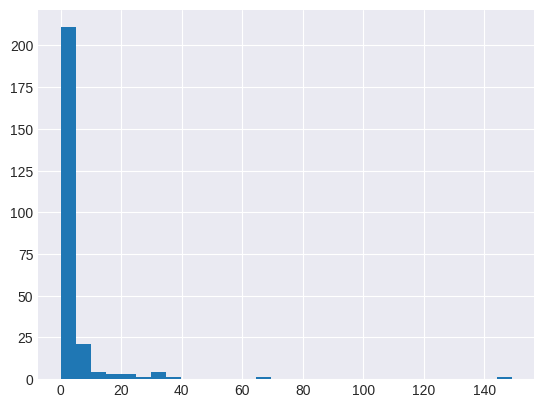

In [7]:
plt.hist(data['numfish'], bins=30);

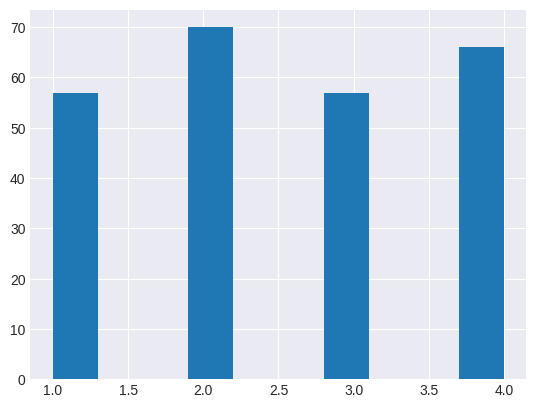

In [8]:
plt.hist(data['persons']);

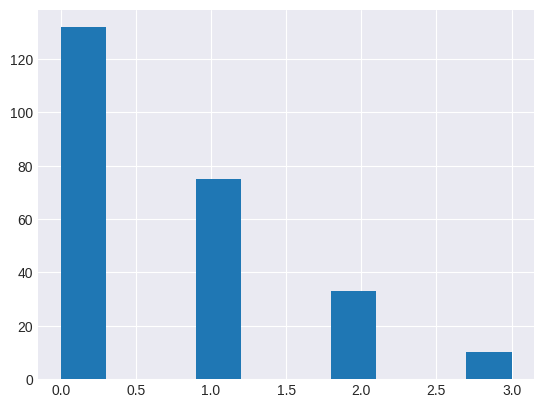

In [9]:
plt.hist(data['child']);

### Setting Priors

Let's pretend we have some prior information that the long-run proportion of people with bait is 80%, and the long-run proportion of campers is 60%. The other parameters I will let default to normal with scaled variance, but you can play around with the reasonable defaults indicated if you are interested (for the sake of comparing types of GLMs, I'll let the data speak largely for itself).

In [10]:
priors = {
#     "Intercept": bmb.Prior("Normal"),
#     "persons": bmb.Prior("DiscreteUniform", lower=1, upper=4),
#     "child": bmb.Prior("Poisson"), mu=0.6),
    "livebait": bmb.Prior("Bernoulli", p=0.8),
    "camper": bmb.Prior("Bernoulli", p=0.6)
}

### Fitting to Data

In [11]:
model_poisson = bmb.Model(
    "numfish ~ livebait + camper + persons + child",
    data,
    family="poisson",
    priors=priors
)

idata_poisson = model_poisson.fit(
    draws=1000,
    target_accept=0.95,
    random_seed=1234,
    chains=4,
    idata_kwargs={"log_likelihood": True}
)

Output()

Output()

Output()

Output()

/usr/local/lib/python3.10/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


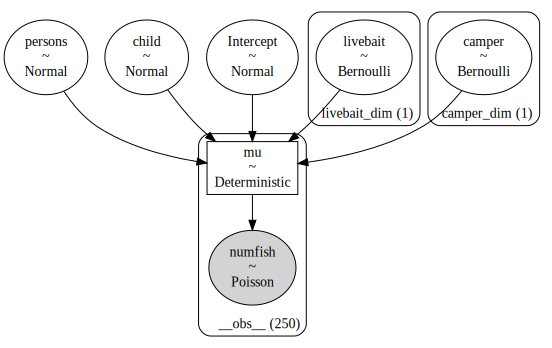

In [12]:
model_poisson.graph()

We can summarize the parameter values as follows.

In [13]:
az.summary(idata_poisson)

/usr/local/lib/python3.10/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/usr/local/lib/python3.10/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-2.907,0.137,-3.162,-2.652,0.003,0.002,1677.0,1966.0,1.0
camper[1],1.000,0.000,1.000,1.000,0.000,0.000,4000.0,4000.0,NaN
child,-1.697,0.081,-1.848,-1.549,0.002,0.001,1637.0,2135.0,1.0
livebait[1],1.000,0.000,1.000,1.000,0.000,0.000,4000.0,4000.0,NaN
persons,1.073,0.039,1.001,1.147,0.001,0.001,1669.0,2108.0,1.0


### Prediction

Posterior predictive checks (in cumulative fashion this time) reveal that the model does not fit the observed data very well.

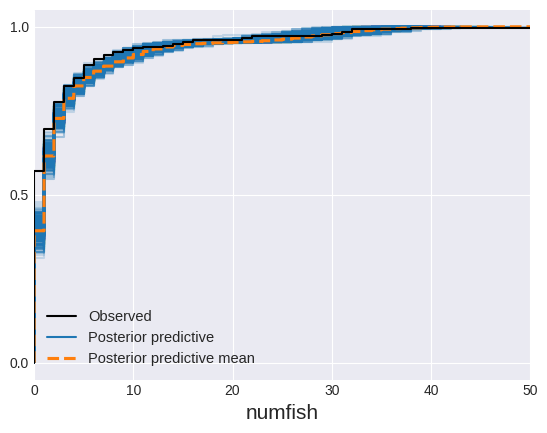

In [14]:
model_poisson.predict(idata_poisson, kind="response")
ax = az.plot_ppc(idata_poisson, num_pp_samples=500, kind="cumulative")
ax.set_xlim(0, 50);

We can use <code>idata.posterior.to_dataframe()</code> to convert the results provided in an Arviz InferenceData object to a Pandas dataframe.

In [15]:
posterior_df = idata_poisson.posterior.to_dataframe()
posterior_df.head()

Intercept  camper    child  \
chain draw camper_dim livebait_dim __obs__                               
0     0    1          1            0        -2.954357       1 -1.76012   
                                   1        -2.954357       1 -1.76012   
                                   2        -2.954357       1 -1.76012   
                                   3        -2.954357       1 -1.76012   
                                   4        -2.954357       1 -1.76012   

                                            livebait   persons        mu  
chain draw camper_dim livebait_dim __obs__                                
0     0    1          1            0               1  1.089177  0.154868  
                                   1               1  1.089177  1.144330  
                                   2               1  1.089177  0.420976  
                                   3               1  1.089177  0.585012  
                                   4               1  1.089177  0.420976

Summarizing the data, we can see that the normally distributed parameter of the Poisson 'numfish' variable has a variance much larger than the mean. This could be a reason for poor fit from the Poisson distribution.

In [16]:
posterior_df['mu'].describe()

,mu
count,1000000.000000
mean,3.299188
std,6.487106
min,0.027471
25%,0.423998
50%,1.086123
75%,3.052849
max,34.850975


## Zero-Inflated Poisson Regression

Recall from the histogram of the target variable above that we have many zeros in the data. This is a fairly common issue to encounter. We want to model count data, but there are more zeros than would allow a Poisson distribution to fit it nicely. Modeling the count of zeros separately from the rest of the distribution is awkward, because then we need a solution to account for the lack of zeros in the remaining data. A more elegant solution is to introduce an extra parameter which allows the distribution to account for an arbitrary level of zeros, and this is the goal of zero-inflated Poisson (ZIP) regression.

ZIP regression introduces another parameter $\psi$ that modulates the PMF. The PMF of the zero-inflated Poisson distribution is:

$P(X=k)  =
\begin{cases}
  \psi + (1-\psi) ~exp(\lambda), ~~~~~~~~~\text{if} ~k=0  \\
  (1-\psi) ~exp(-\lambda) \lambda^k/k!, ~~~~\text{if} ~k \in \{1,2,\ldots\}
\end{cases}$

when $\psi=0$, the zero-inflated Poisson reduces to the Poisson distribution.

The mean and variance are:
- $E(X) = \lambda(1 - \psi)$
- $Var(X) = \lambda(1 - \psi)(1 + \lambda \psi)$

#### Setting Priors

I'll use the same priors above, allowing the assumption of a flat prior on psi.

In [17]:
  priors = {
  #     "Intercept": bmb.Prior("Normal"),
  #    "persons": bmb.Prior("DiscreteUniform", lower=1, upper=4),
  #    "child": bmb.Prior("Poisson", mu=0.6),
      "livebait": bmb.Prior("Bernoulli", p=0.8),
      "camper": bmb.Prior("Bernoulli", p=0.6)
  }

In [18]:
model_zip = bmb.Model(
    "numfish ~ livebait + camper + persons + child",
    data,
    family="zero_inflated_poisson",
    priors=priors
)

idata_zip = model_zip.fit(
    draws=1000,
    target_accept=0.95,
    chains=4,
    idata_kwargs={"log_likelihood": True}
)

Output()

Output()

Output()

Output()

/usr/local/lib/python3.10/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


#### Fitting to Data

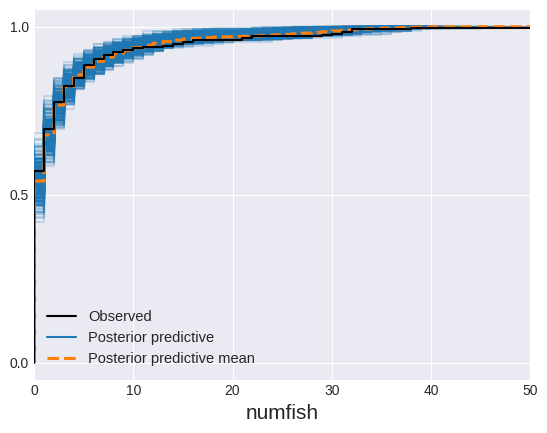

In [19]:
model_zip.predict(idata_zip, kind="response")
ax = az.plot_ppc(idata_zip, num_pp_samples=500, kind="cumulative")
ax.set_xlim(0, 50);

This is a much better fit to the data. The variability of posterior predictions is pretty much split down the middle by the observed data.

#### Model Comparison

To verify that the second approach is better, we can perform cross-validation on the InferenceData objects. Higher <code>elpd_loo</code> and <code>p_loo</code> scores are better. <code>p_loo</code> penalizes for the number of parameters.

In [20]:
models_dict = {
    "poisson": idata_poisson,
    "zip": idata_zip
}
df_compare = az.compare(models_dict)
df_compare

/usr/local/lib/python3.10/dist-packages/arviz/stats/stats.py:789: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/arviz/stats/stats.py:789: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
zip,0,-773.584199,49.992364,0.000000,0.585036,165.193285,0.000000,True,log
poisson,1,-824.745161,47.106932,51.160962,0.414964,172.517210,24.218603,True,log


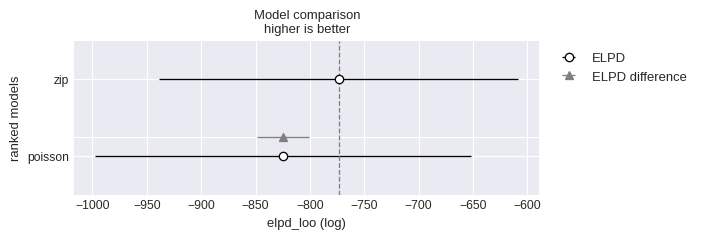

In [21]:
az.plot_compare(df_compare, insample_dev=False);

#### Interpret Predictions

We can use the <code>interpret.plot_predictions</code> function to view the conditional effect of one variable on another in terms of prediction. For example, below, the number of fish caught depending on the number of persons per group. The <code>prob=0.95</code> argument specifies the size of highest density interval to provide.

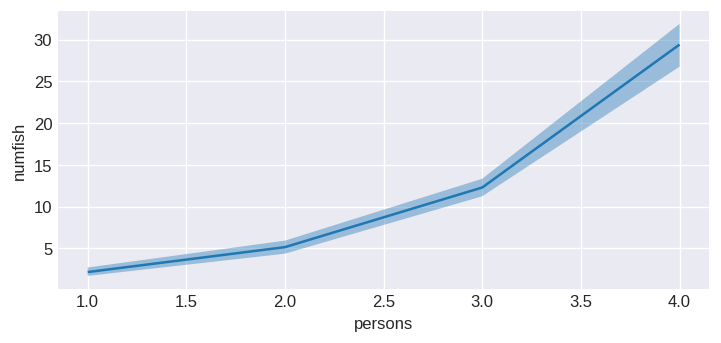

In [22]:
fig, ax = plt.subplots(figsize=(7, 3), dpi=120)
bmb.interpret.plot_predictions(model_zip, idata_zip, conditional='persons', ax=ax, prob=0.95);

Similarly, we can compare number of fish caught to number of children in the group, and see that there is a decreasing relationship.

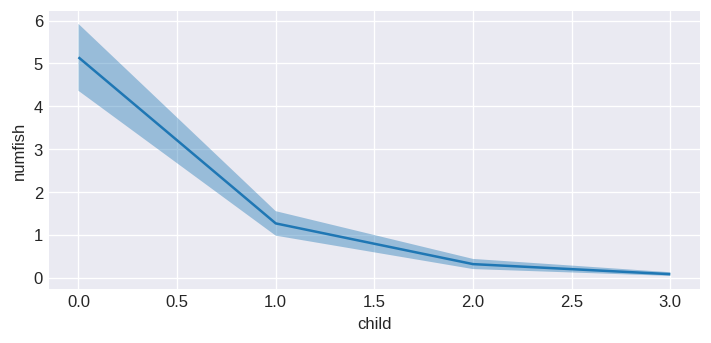

In [23]:
fig, ax = plt.subplots(figsize=(7, 3), dpi=120)
bmb.interpret.plot_predictions(model_zip, idata_zip, conditional='child', ax=ax ,prob=0.95);

We can also use the <code>interpret.plot_comparisons</code> feature to view the conditional effect of one variable on another, while broken out by other variables. For example, below, we have number of persons on the x-axis, number of fish on the y-axis, and a breakout by number of children. As we would expect based on the prior charts, number of fish increases with the size of group, but does so in greatest fashion for the groups with less children.

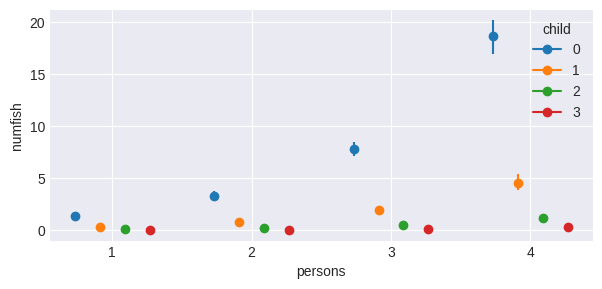

In [24]:
fig, ax = bmb.interpret.plot_comparisons(
    model=model_zip,
    idata=idata_zip,
    contrast={"livebait": [0, 1]},
    conditional=["persons", "child"],
    prob=0.95
)
fig.set_size_inches(7, 3)

Similarly, we can examine the contrast in number of fish caught between those with live bait and those without, in the context of another variable such as how many children were present.

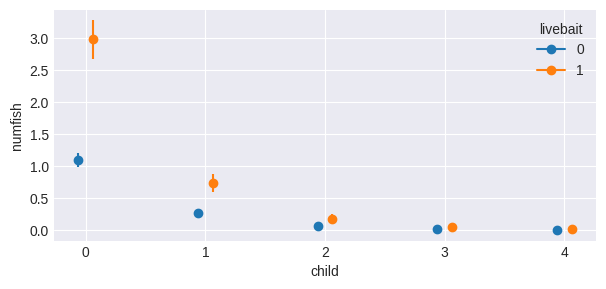

In [25]:
fig, ax = bmb.interpret.plot_comparisons(
    model=model_zip,
    idata=idata_zip,
    contrast={"persons": [1, 2]},
    conditional={"child": [0, 1, 2, 3, 4], "livebait": [0, 1]},
    prob=0.95
)
fig.set_size_inches(7, 3)

## Negative Binomial Regression

As mentioned above, a key assumption of the Poisson GLM is that the mean $\lambda$ is roughly equal to the variance. Variability is said to be overdispersed if the observed variance exceeds that expected by the model, and if a count variable is too overdispersed for the Poisson model, the Negative Binomial offers a suitable alternative. It too is suited to count data, but it does not constrain variance to be equal to the mean.

The PMF of the Negative Binomial distribution is:

$f(x|\mu, \alpha) = \binom{x + \alpha - 1}{x} \left( \frac{\alpha}{\mu + \alpha} \right)^{\alpha} \left( \frac{\mu}{\mu + \alpha} \right)^x$

$\alpha$ is a dispersion parameter, for which the Exponential provides a reasonable prior. For large $\alpha$, $Var(Y) \approx E(Y)$, and $Y$ behaves much like a Poisson random variable. For small $\alpha$, $Y$ is overdispersed compared to a Poisson variable.

As a side note, the Negative Binomial can be alternatively parameterized in terms of $n = \alpha$ and $p = \alpha / (\mu + \alpha)$, in which case it can be interpreted as the probability of x failures before the $n^{th}$ success.

The dataset corrsponds to a survey asking people how many murder victims they each know of. So again, we expect low counts, and a lot of zeros.

In [ ]:
data = pd.read_csv('https://raw.githubusercontent.com/pw598/Articles/main/data/murders.csv')
data.head()

,observation,response
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


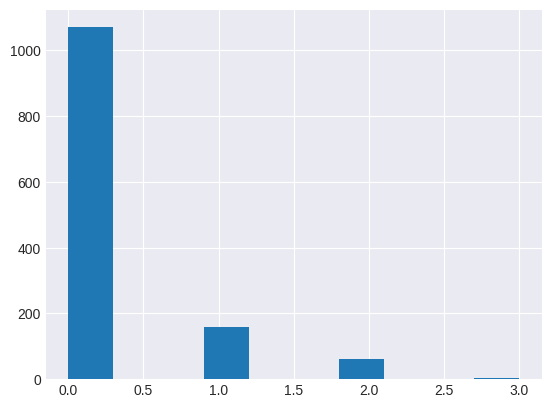

In [ ]:
plt.hist(data['response']);

#### Fitting to Data

In [ ]:
model_nb = bmb.Model("response ~ 0 + observation", data, family="negativebinomial")
idata_nb = model_nb.fit(idata_kwargs={"log_likelihood": True})

Output()

Output()

#### Prediction

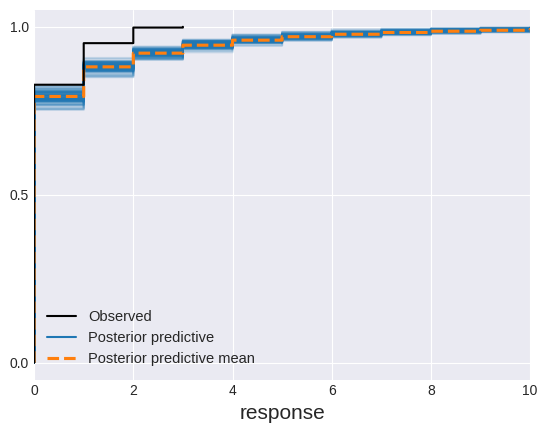

In [ ]:
model_nb.predict(idata_nb, kind="response")
ax = az.plot_ppc(idata_nb, num_pp_samples=100, kind='cumulative')
ax.set_xlim(0, 10);

## Zero-Inflated Negative Binomial Regression

Like the zero-inflated Poisson, the zero-inflated Negative Binomial injects an additional parameter which allows the distribution to account for the additional variability. However, it's not a built-in family of <code>bambi</code>, so we use some additional syntax below.

In [ ]:
likelihood = bmb.Likelihood("ZeroInflatedNegativeBinomial", params=["mu", "psi", "alpha"])
links = {"mu": "log", "psi": "logit", "alpha": "log"}
zip_family = bmb.Family("zip", likelihood, links)

#### Setting Priors

We can set priors as follows:

In [ ]:
# this prior regularizes the results in a helpful direction, but involves no true expert knowledge
priors = {"psi": bmb.Prior("Beta", alpha=1, beta=25), "alpha": bmb.Prior("Beta", alpha=1, beta=1)}

#### Fitting to Data

And then fit the model.

In [ ]:
model_zinb = bmb.Model("response ~ 0 + observation", data, family=zip_family, priors=priors)
idata_zinb = model_zinb.fit(target_accept=0.95, idata_kwargs={"log_likelihood": True})

Output()

Output()

#### Prediction

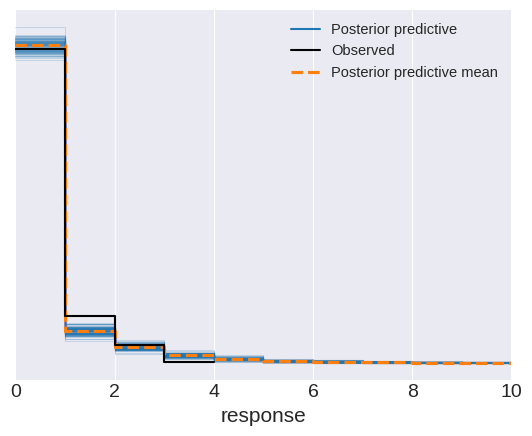

In [ ]:
model_zinb.predict(idata_zinb, kind="response")
ax = az.plot_ppc(idata_zinb, num_pp_samples=100)
ax.set_xlim(0, 10);

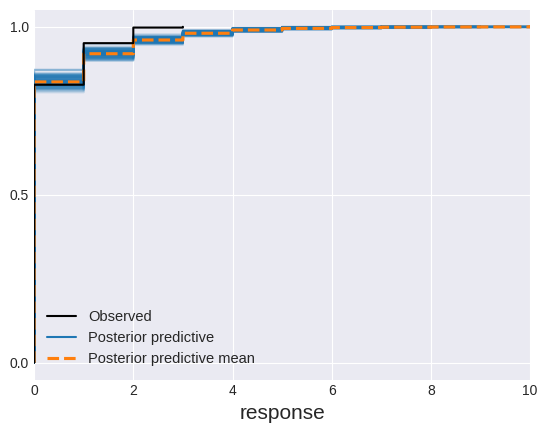

In [ ]:
model_zinb.predict(idata_zinb, kind="response")
ax = az.plot_ppc(idata_zinb, num_pp_samples=100, kind="cumulative")
ax.set_xlim(0, 10);

#### Model Comparison

We can compare the plain Negative Binomial to the zero-inflated model as such:

In [ ]:
models_dict = {
    "nb": idata_nb,
    "zinb": idata_zinb
}
df_compare = az.compare(models_dict)
df_compare

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
zinb,0,-800.462441,1.137492,0.000000,1.0,34.868927,0.000000,False,log
nb,1,-872.363742,1.417251,71.901301,0.0,34.461746,1.342238,False,log


We see that while the zero-inflated model fits better according the the <code>elpd_loo</code> score (as the visual suggested it would), the <code>p_loo</code> score is actually lower for the zero-inflated model because it has more parameters.

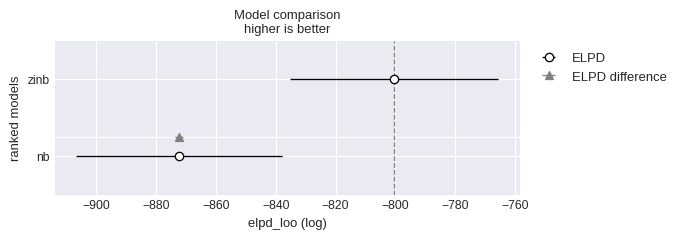

In [ ]:
az.plot_compare(df_compare, insample_dev=False);

## Gamma Regression

What if we're measuring a process that produces positive real values that aren't counts? For parameters that live in this domain, we often consider the Exponential distribution as a prior, however this suffers from having only one parameter; once $\lambda$ is determined, so is both the shape and the rate. Alternatives include truncated distributions like the HalfNormal and HalfStudentT, as well as the Gamma distribution, which has shape parameter $\alpha$ and rate parameter $\beta$. The Exponential is actually a special case of the Gamma, where $\alpha=1$.

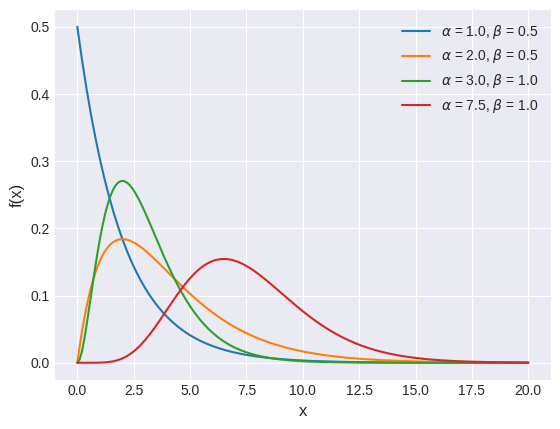

In [ ]:
import scipy.stats as st
x = np.linspace(0, 20, 200)
alphas = [1., 2., 3., 7.5]
betas = [.5, .5, 1., 1.]
for a, b in zip(alphas, betas):
    pdf = st.gamma.pdf(x, a, scale=1.0/b)
    plt.plot(x, pdf, label=r'$\alpha$ = {}, $\beta$ = {}'.format(a, b))
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.legend(loc=1)
plt.show()

For data, we'll look at the <code>carclaims</code> dataset which is built into <code>bambi</code>. The features are as follows:

In [ ]:
data = bmb.load_data("carclaims")
data = data[data["claimcst0"] > 0]
data.head()

,veh_value,exposure,clm,numclaims,claimcst0,veh_body,veh_age,gender,area,agecat
14,1.66,0.484600,1,1,669.509999,SEDAN,3,M,B,6
16,1.51,0.993840,1,1,806.609999,SEDAN,3,F,F,4
17,0.76,0.539357,1,1,401.805451,HBACK,3,M,C,4
40,1.89,0.654346,1,2,1811.709997,STNWG,3,M,F,2
64,4.06,0.851472,1,1,5434.439987,STNWG,2,M,F,3


Claim amount is the target variable, and is distributed as follows:

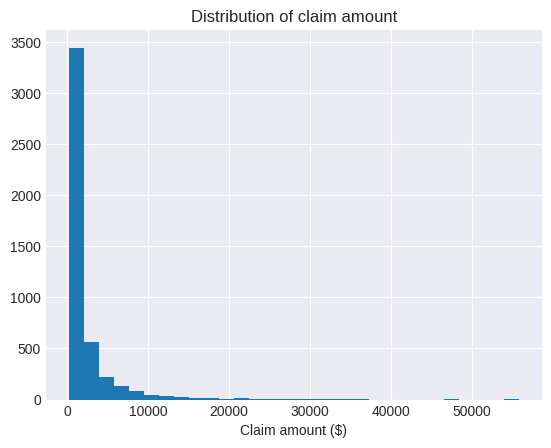

In [ ]:
plt.hist(data["claimcst0"], bins=30)
plt.title("Distribution of claim amount")
plt.xlabel("Claim amount ($)");

#### Exponential Regression

For the sake of comparison, we'll first try fitting a simple Exponential model. Priors can be added using the same syntax as the other fit operations above.

In [ ]:
model_exp = bmb.Model(
    "claimcst0 ~ agecat + gender + numclaims + veh_age + exposure",
    data,
    family="exponential",
    link="log",
    categorical="agecat" #,
    # priors=priors
)
idata_exp = model_exp.fit(tune=2000, target_accept=0.9, idata_kwargs={"log_likelihood": True})

Output()

Output()

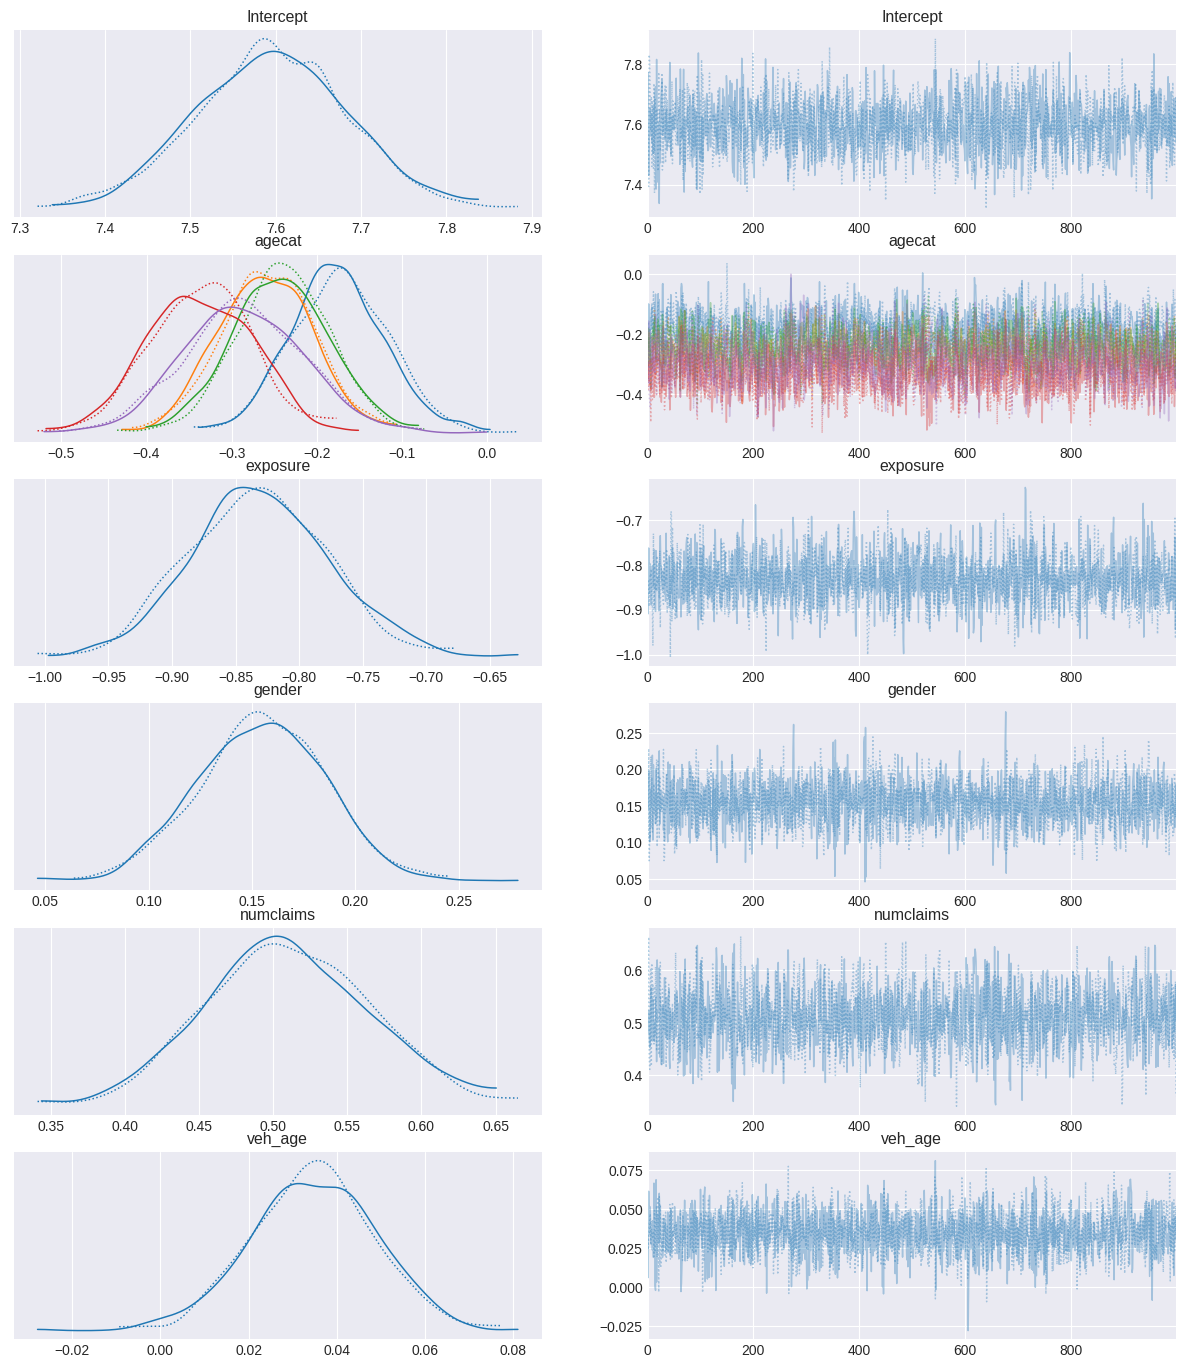

In [ ]:
az.plot_trace(idata_exp, figsize=(15,17));

#### Prediction

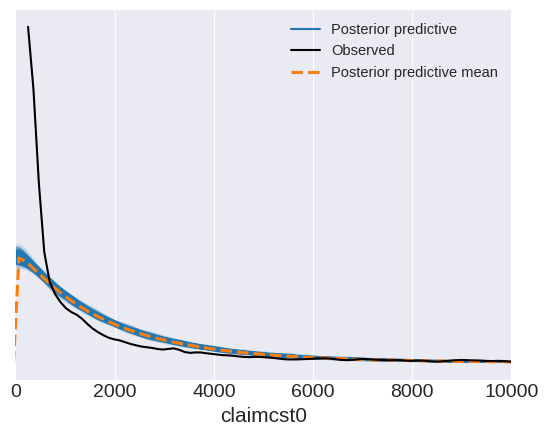

In [ ]:
model_exp.predict(idata_exp, kind="response")
ax = az.plot_ppc(idata_exp, num_pp_samples=500);
ax.set_xlim(0, 10000);

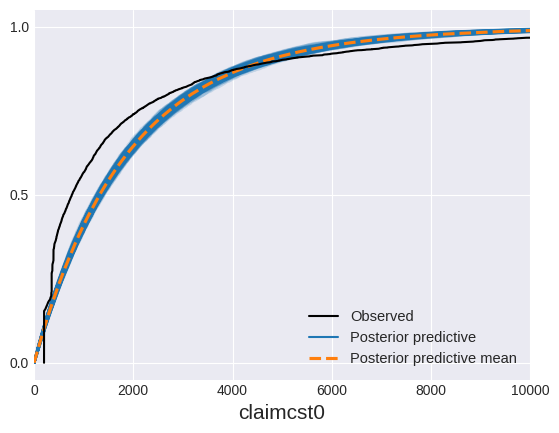

In [ ]:
model_exp.predict(idata_exp, kind="response")
ax = az.plot_ppc(idata_exp, num_pp_samples=500, kind="cumulative");
ax.set_xlim(0, 10000);

There seems to be some room for improvement. Let's try a Gamma model.

### Gamma Regression

In [ ]:
# these priors skew the target variable such that it better fits the data
priors = {"alpha": 0.4, "beta": 1.5}

In [ ]:
model_gamma = bmb.Model(
    "claimcst0 ~ agecat + gender + numclaims + veh_age + exposure",
    data,
    family="gamma",
    link="log",
    categorical="agecat",
    priors=priors
)
idata_gamma = model_gamma.fit(tune=2000, target_accept=0.9, idata_kwargs={"log_likelihood": True})

Output()

Output()

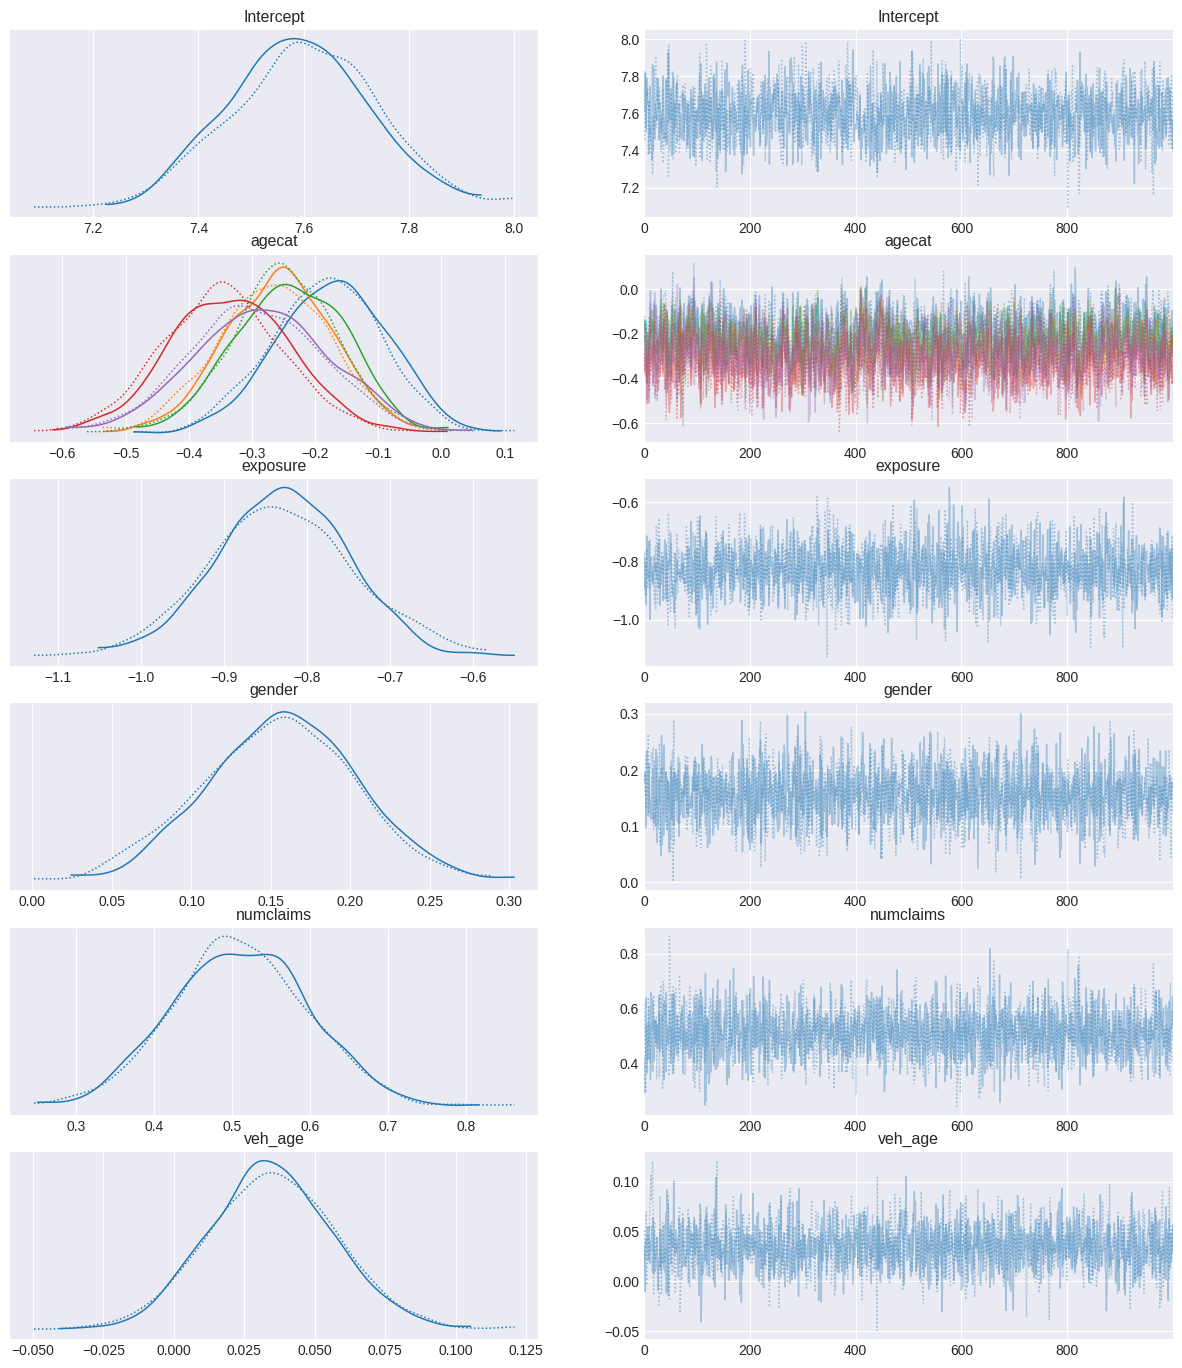

In [ ]:
az.plot_trace(idata_gamma, figsize=(15,17));

#### Prediction

And we can see that the results look much better.

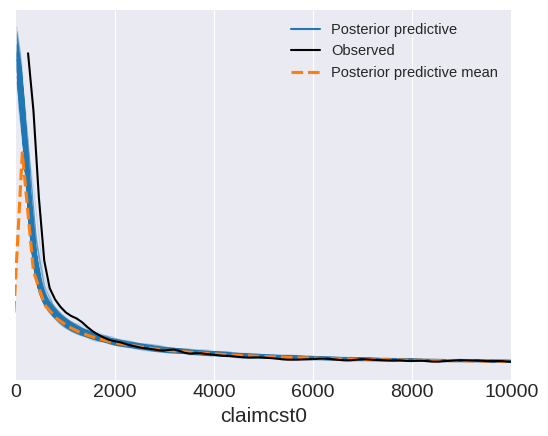

In [ ]:
model_gamma.predict(idata_gamma, kind="response")
ax = az.plot_ppc(idata_gamma, num_pp_samples=500);
ax.set_xlim(0, 10000);

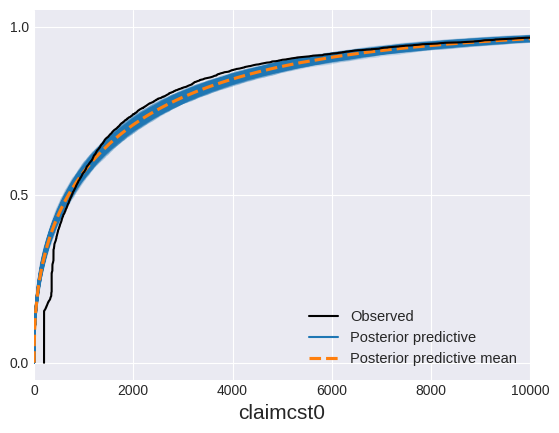

In [ ]:
model_gamma.predict(idata_gamma, kind="response")
ax = az.plot_ppc(idata_gamma, num_pp_samples=500, kind='cumulative');
ax.set_xlim(0, 10000);

With that, we will conclude this article. The next one in the series is on Bayesian networks, and can be found <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Bayesian%20Inference%20IV%20-%20EBayesian%20Networks%20Discrete.ipynb">here</a>.

## References

- Davidson-Pilon, C. Bayesian Methods for Hackers. https://dataorigami.net/Probabilistic-Programming-and-Bayesian-Methods-for-Hackers/#contents

- Johnson, A. A., Ott, M. Q., & Dogucu, M. (2012). Bayes Rules! CRC Press. https://www.bayesrulesbook.com/

- Martin, O. (2024). Bayesian Analysis with Python (3rd ed.). Packt. https://www.packtpub.com/en-ca/product/bayesian-analysis-with-python-9781805127161

- (n.d.). Bambi User Docs. https://bambinos.github.io/bambi/

- (n.d.). Bambi User Docs: Examples. https://bambinos.github.io/bambi/notebooks/

- (n.d.). PyMC User Docs: Examples. https://www.pymc.io/projects/examples/en/latest/gallery.html